In [534]:
import matplotlib.pyplot as plt
import numpy as np
import CXRO_Tools
from scipy import interpolate

In [535]:
cxro = CXRO_Tools.Filter_Transmission()

In [536]:
Si_transmission_data = cxro.get_transmission('Si', 5, 30, 2000, 100)
energies = [i[0] for i in Si_transmission_data]
transmission = [i[1] for i in Si_transmission_data]


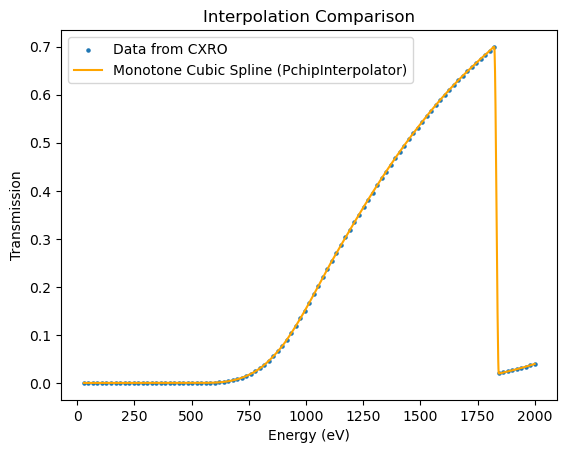

In [537]:
plt.scatter(energies, transmission, label = "Data from CXRO", s=5)
interpolated_transmission = interpolate.PchipInterpolator(energies, transmission) # I like monotone cubic spline. Doesn't overshoot, don't need twice differentiable
test_range = range(30, 2000, 1)
plt.plot(test_range, interpolated_transmission(test_range), label="Monotone Cubic Spline (PchipInterpolator)", color='orange')
plt.legend()
plt.title("Interpolation Comparison")
plt.xlabel("Energy (eV)")
plt.ylabel("Transmission")
plt.show()

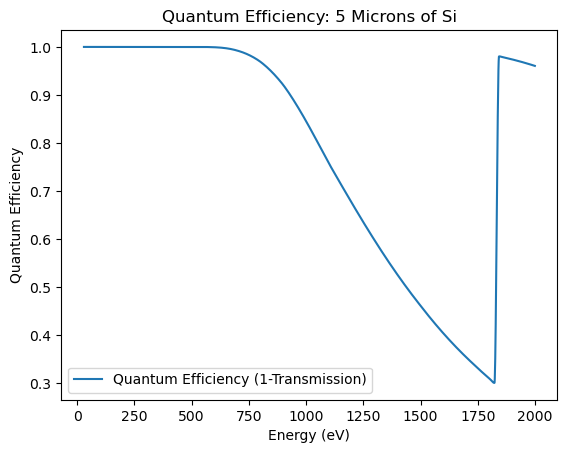

In [538]:
plt.plot(test_range, 1 - interpolated_transmission(test_range), label="Quantum Efficiency (1-Transmission)")
plt.title("Quantum Efficiency: 5 Microns of Si")
plt.xlabel("Energy (eV)")
plt.ylabel("Quantum Efficiency")
plt.legend()
plt.show()

Step 2: plot C and O transmission with Si absorption and check general shape

In [539]:
C_transmission_data = cxro.get_transmission('C', .1, 30, 2000, 100)
C_energies = [i[0] for i in C_transmission_data]
C_transmission = [i[1] for i in C_transmission_data]

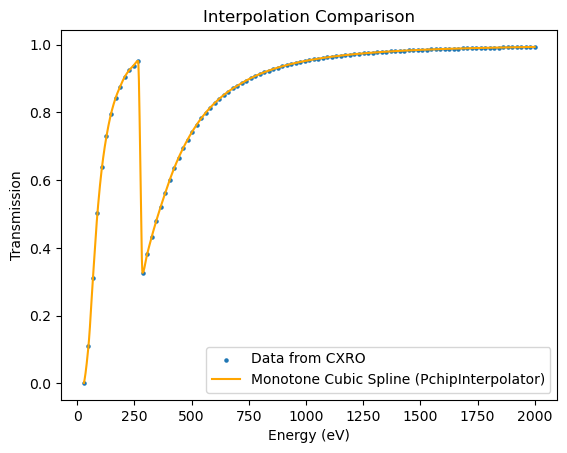

In [540]:
plt.scatter(C_energies, C_transmission, label = "Data from CXRO", s=5)
interpolated_C_transmission = interpolate.PchipInterpolator(C_energies, C_transmission) # I like monotone cubic spline. Doesn't overshoot, don't need twice differentiable
test_range = range(30, 2000, 1)
plt.plot(test_range, interpolated_C_transmission(test_range), label="Monotone Cubic Spline (PchipInterpolator)", color='orange')
plt.legend()
plt.title("Interpolation Comparison")
plt.xlabel("Energy (eV)")
plt.ylabel("Transmission")
plt.show()

Oxygen line present in result but O transmission data does not affect results for thin layers- switched to SiO2 based on lecture slides and works well

In [541]:
O_transmission_data = cxro.get_transmission('SiO2', .1, 30, 2000, 100)
O_energies = [i[0] for i in O_transmission_data]
O_transmission = [i[1] for i in O_transmission_data]

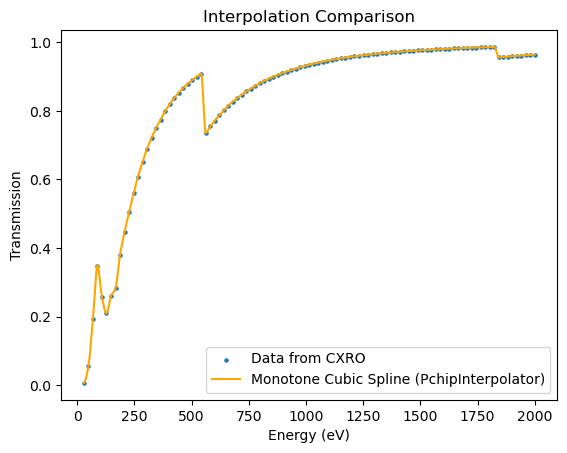

In [542]:
plt.scatter(O_energies, O_transmission, label = "Data from CXRO", s=5)
interpolated_O_transmission = interpolate.PchipInterpolator(O_energies, O_transmission) # I like monotone cubic spline. Doesn't overshoot, don't need twice differentiable
test_range = range(30, 2000, 1)
plt.plot(test_range, interpolated_O_transmission(test_range), label="Monotone Cubic Spline (PchipInterpolator)", color='orange')
plt.legend()
plt.title("Interpolation Comparison")
plt.xlabel("Energy (eV)")
plt.ylabel("Transmission")
plt.show()

Thought to try silicon nitride based on QE equation in lecture slides- lines do not match our results so discarded

In [543]:
'''N_transmission_data = cxro.get_transmission('Si3N4', .1, 30, 2000, 100)
N_energies = [i[0] for i in N_transmission_data]
N_transmission = [i[1] for i in N_transmission_data]
plt.scatter(N_energies, N_transmission, label = "Data from CXRO", s=5)
interpolated_N_transmission = interpolate.PchipInterpolator(N_energies, N_transmission) # I like monotone cubic spline. Doesn't overshoot, don't need twice differentiable
test_range = range(30, 2000, 1)
plt.plot(test_range, interpolated_N_transmission(test_range), label="Monotone Cubic Spline (PchipInterpolator)", color='orange')
plt.legend()
plt.title("Interpolation Comparison")
plt.xlabel("Energy (eV)")
plt.ylabel("Transmission")
plt.show()'''

'N_transmission_data = cxro.get_transmission(\'Si3N4\', .1, 30, 2000, 100)\nN_energies = [i[0] for i in N_transmission_data]\nN_transmission = [i[1] for i in N_transmission_data]\nplt.scatter(N_energies, N_transmission, label = "Data from CXRO", s=5)\ninterpolated_N_transmission = interpolate.PchipInterpolator(N_energies, N_transmission) # I like monotone cubic spline. Doesn\'t overshoot, don\'t need twice differentiable\ntest_range = range(30, 2000, 1)\nplt.plot(test_range, interpolated_N_transmission(test_range), label="Monotone Cubic Spline (PchipInterpolator)", color=\'orange\')\nplt.legend()\nplt.title("Interpolation Comparison")\nplt.xlabel("Energy (eV)")\nplt.ylabel("Transmission")\nplt.show()'

Small feature at ~700 eV in Measured QE plot matches Fe absorption. Fe is sometimes a contaminant introduced in CMOS fabrication (https://www.sisusemi.com/blog/atomic-level-defects-cmos-image-sensors/) and "is a primary driver for yield loss, noise performance and product reliability"

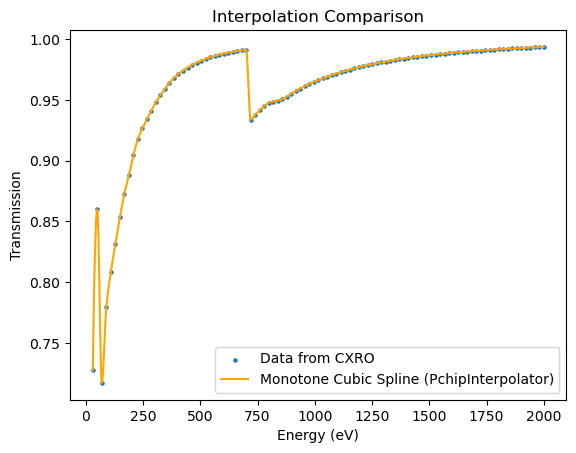

In [544]:
Fe_transmission_data = cxro.get_transmission('Fe', .005, 30, 2000, 100)
Fe_energies = [i[0] for i in Fe_transmission_data]
Fe_transmission = [i[1] for i in Fe_transmission_data]
plt.scatter(Fe_energies, Fe_transmission, label = "Data from CXRO", s=5)
interpolated_Fe_transmission = interpolate.PchipInterpolator(Fe_energies, Fe_transmission) # I like monotone cubic spline. Doesn't overshoot, don't need twice differentiable
test_range = range(30, 2000, 1)
plt.plot(test_range, interpolated_Fe_transmission(test_range), label="Monotone Cubic Spline (PchipInterpolator)", color='orange')
plt.legend()
plt.title("Interpolation Comparison")
plt.xlabel("Energy (eV)")
plt.ylabel("Transmission")
plt.show()

Combine all with QE=[1- Si transmission][C transmission][O transmission]

In [545]:
transmission= np.array(transmission)
C_transmission= np.array(C_transmission)
O_transmission= np.array(O_transmission)
QE= (1- transmission)*C_transmission*O_transmission*Fe_transmission#*N_transmission doesn't match results

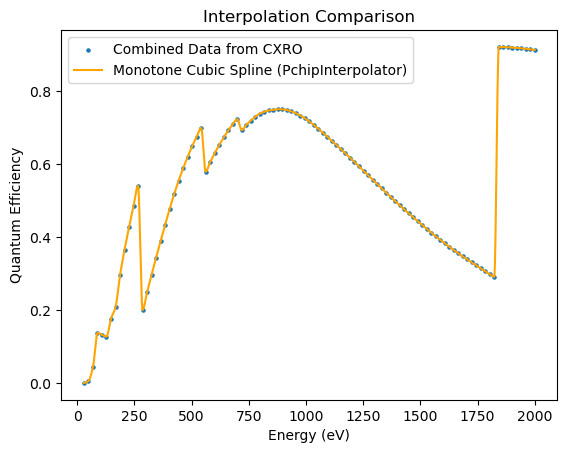

In [546]:
plt.scatter(energies, QE, label = "Combined Data from CXRO", s=5)
interpolated_QE = interpolate.PchipInterpolator(energies, QE) # I like monotone cubic spline. Doesn't overshoot, don't need twice differentiable
test_range = range(30, 2000, 1)
plt.plot(test_range, interpolated_QE(test_range), label="Monotone Cubic Spline (PchipInterpolator)", color='orange')
plt.legend()
plt.title("Interpolation Comparison")
plt.xlabel("Energy (eV)")
plt.ylabel("Quantum Efficiency")
plt.show()